In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .config("spark.driver.memory","2g") \
    .config("spark.executor.memory", "18g") \
    .config('spark.executor.instances', 7) \
    .getOrCreate()

In [3]:
spark

In [7]:
path = r"/expanse/lustre/projects/uci157/hkwon2/shared"
df = spark.read.csv(
    path + "/*.tsv",
    header=True,
    inferSchema=True,
    sep="\t"
)
parquet_path = r"/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews.parquet"
df.write.parquet(parquet_path)
df = spark.read.parquet(parquet_path)

In [8]:
df.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: integer (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: string (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)



In [7]:
df.describe("star_rating", "helpful_votes", "total_votes").show()

+-------+------------------+------------------+-----------------+
|summary|       star_rating|     helpful_votes|      total_votes|
+-------+------------------+------------------+-----------------+
|  count|         109828733|         109828726|        109828726|
|   mean| 4.171742636803417| 1.910618466065062|2.580553807024949|
| stddev|1.2788198675779987|21.633604256060348|23.56154125612763|
|    min|                 1|                 0|                0|
|    max|                 5|             47524|            48362|
+-------+------------------+------------------+-----------------+



In [16]:
from pyspark.sql.functions import col, sum as spark_sum, round

df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) 
    for c in df.columns
]).show()

+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+
|marketplace|customer_id|review_id|product_id|product_parent|product_title|product_category|star_rating|helpful_votes|total_votes|vine|verified_purchase|review_headline|review_body|review_date|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+
|          0|          0|        0|         0|             0|            0|            1753|       1787|         1794|       1794|1794|             1794|           2044|      12438|       8243|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+



In [9]:
total = df.count()
unique_reviews = df.select("review_id").distinct().count()
print(f"Total rows: {total}")
print(f"Unique review_ids: {unique_reviews}")
print(f"Duplicate review_ids: {total - unique_reviews}")

Total rows: 109830520
Unique review_ids: 104582187
Duplicate review_ids: 5248333


In [10]:
# Unique values
print("Unique categories:", df.select("product_category").distinct().count())
print("Unique marketplaces:", df.select("marketplace").distinct().count())

df.select("vine").distinct().show()
df.select("verified_purchase").distinct().show()

Unique categories: 84
Unique marketplaces: 1
+----+
|vine|
+----+
|   N|
|   Y|
|NULL|
+----+

+-----------------+
|verified_purchase|
+-----------------+
|                Y|
|                N|
|             NULL|
+-----------------+



In [11]:
# Star rating
df.groupBy("star_rating") \
  .count() \
  .orderBy("star_rating") \
  .show()

+-----------+--------+
|star_rating|   count|
+-----------+--------+
|       NULL|    1787|
|          1| 9436073|
|          2| 5491915|
| 2011-01-24|       1|
| 2013-05-22|       1|
| 2014-03-11|       1|
| 2014-04-16|       1|
| 2015-02-11|       1|
| 2015-06-05|       1|
| 2015-07-27|       1|
|          3| 8902272|
|          4|18941870|
|          5|67056596|
+-----------+--------+



In [12]:
# Reviews per category
df.groupBy("product_category") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(40)

+--------------------+-------+
|    product_category|  count|
+--------------------+-------+
|            Wireless|9024643|
|                  PC|6965592|
|         Mobile_Apps|6507959|
|Digital_Ebook_Pur...|6350566|
|           Video DVD|6166022|
|             Apparel|5906444|
|               Music|5530245|
|Health & Personal...|5332286|
|              Beauty|5115504|
|Digital_Video_Dow...|5115244|
|                Toys|4922020|
|              Sports|4853699|
|               Shoes|4374299|
|               Books|3944315|
|          Automotive|3514932|
|         Electronics|3105320|
|     Office Products|2644716|
|        Pet Products|2643619|
|             Grocery|2402449|
|            Outdoors|2305587|
|              Camera|1818950|
|         Video Games|1801471|
|Digital_Music_Pur...|1796747|
|                Baby|1758834|
|               Tools|1748605|
|             Watches| 971462|
| Musical Instruments| 915726|
|           Furniture| 792121|
|               Video| 427319|
|       

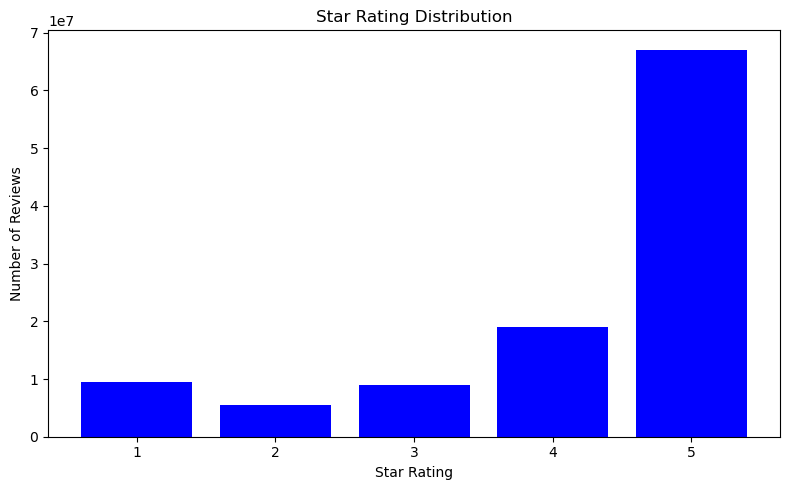

In [37]:
import matplotlib.pyplot as plt

star_data = df.filter(col("star_rating").isin(["1","2","3","4","5"])) \
    .groupBy("star_rating") \
    .count() \
    .orderBy("star_rating") \
    .toPandas()

plt.figure(figsize=(8,5))
plt.bar(star_data["star_rating"], star_data["count"], color="blue")
plt.title("Star Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

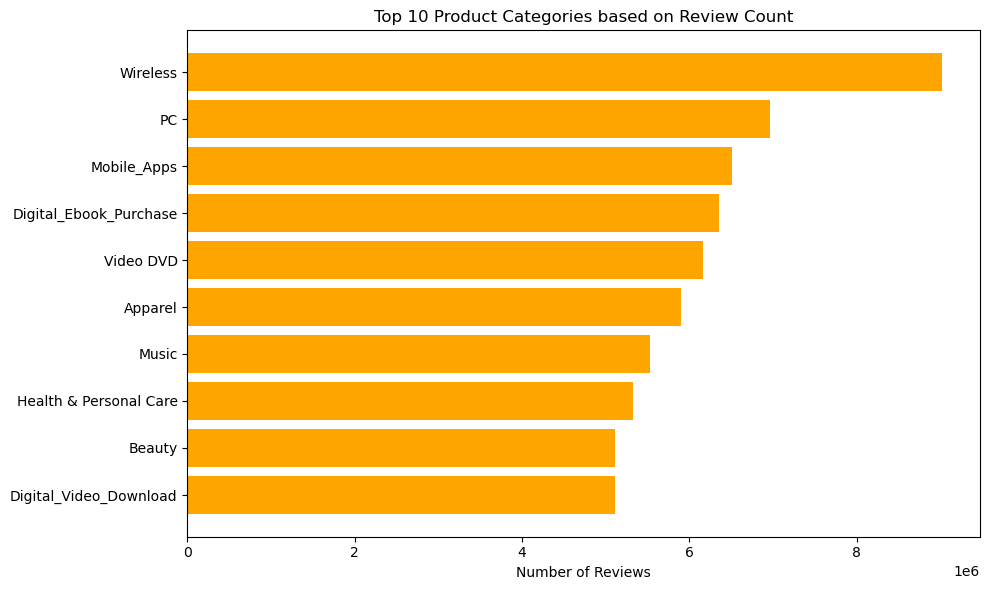

In [38]:
cat_data = df.groupBy("product_category") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(10,6))
plt.barh(cat_data["product_category"], cat_data["count"], color="orange")
plt.title("Top 10 Product Categories based on Review Count")
plt.xlabel("Number of Reviews")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


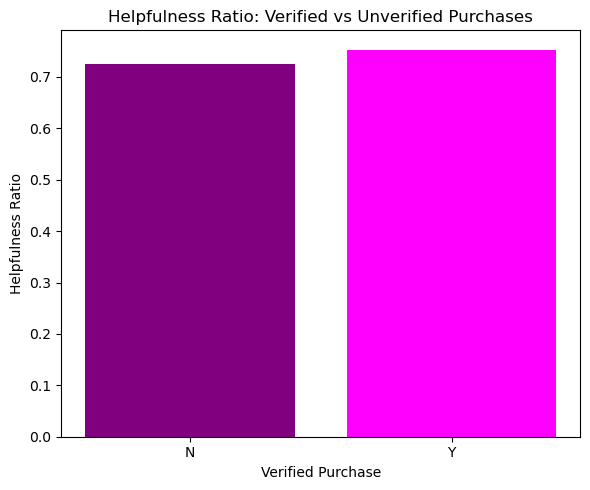

In [39]:
from pyspark.sql.functions import col, round, sum as spark_sum

verified_data = df.filter(
    (col("total_votes") > 0) &
    (col("verified_purchase").isin(["Y", "N"]))
).groupBy("verified_purchase") \
    .agg(round(
        spark_sum(col("helpful_votes")) / spark_sum(col("total_votes")), 3
    ).alias("helpfulness_ratio")) \
    .orderBy("verified_purchase") \
    .toPandas()

plt.figure(figsize=(6,5))
plt.bar(verified_data["verified_purchase"], verified_data["helpfulness_ratio"], color=["purple", "magenta"])
plt.title("Helpfulness Ratio: Verified vs Unverified Purchases")
plt.xlabel("Verified Purchase")
plt.ylabel("Helpfulness Ratio")
plt.tight_layout()
plt.show()

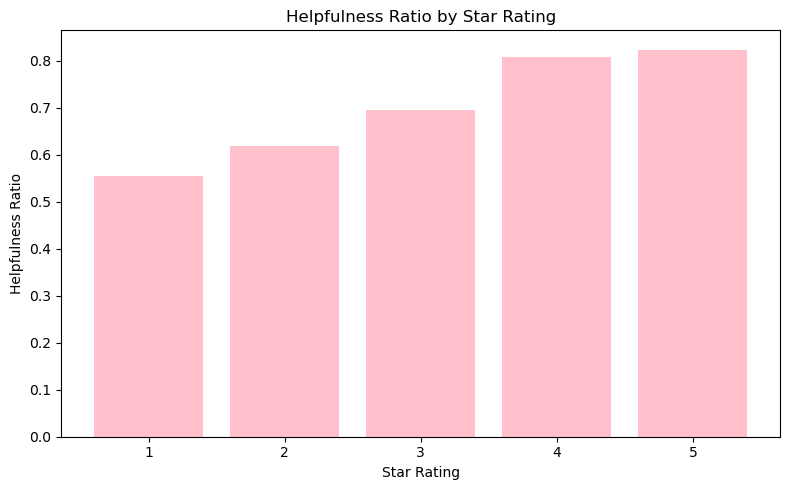

In [40]:
star_help = df.filter(
    (col("total_votes") > 0) &
    (col("star_rating").isin(["1","2","3","4","5"]))
).groupBy("star_rating") \
  .agg(round(
      spark_sum(col("helpful_votes")) / spark_sum(col("total_votes")), 3
  ).alias("helpfulness_ratio")) \
  .orderBy("star_rating") \
  .toPandas()

plt.figure(figsize=(8,5))
plt.bar(star_help["star_rating"], star_help["helpfulness_ratio"], color="pink")
plt.title("Helpfulness Ratio by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Helpfulness Ratio")
plt.tight_layout()
plt.show()

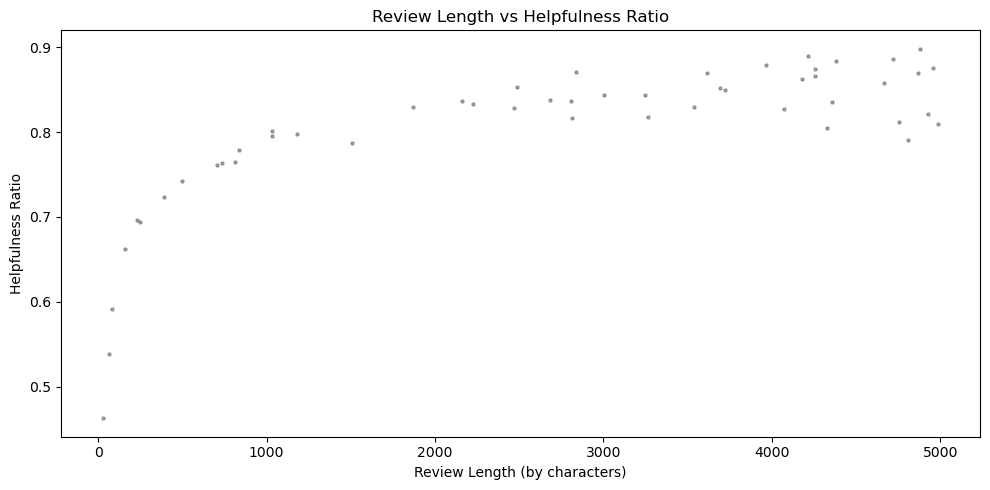

In [41]:
from pyspark.sql.functions import col, round, sum as spark_sum, length

length_data = df.filter(
    (col("total_votes") > 0) &
    (col("review_body").isNotNull())
).withColumn("review_length", length(col("review_body"))) \
    .filter(col("review_length") < 5000) \
    .groupBy("review_length") \
    .agg(round(
        spark_sum(col("helpful_votes")) / spark_sum(col("total_votes")), 3
    ).alias("helpfulness_ratio")) \
    .orderBy("review_length") \
    .toPandas()

length_data = length_data.sample(frac=0.01, random_state=42)

plt.figure(figsize=(10,5))
plt.scatter(length_data["review_length"], length_data["helpfulness_ratio"], alpha=0.3, s=5, color="black")
plt.title("Review Length vs Helpfulness Ratio")
plt.xlabel("Review Length (by characters)")
plt.ylabel("Helpfulness Ratio")
plt.tight_layout()
plt.show()

In [42]:
#might need to address 
from pyspark.sql import SQLContext
sqlContext = SQLContext(spark.sparkContext)

/usr/local/spark/python/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [ ]:
df.createOrReplaceTempView("reviews")

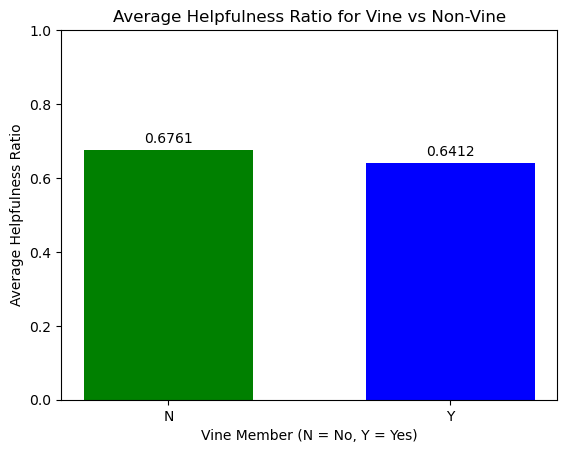

In [30]:
vine_pdf = sqlContext.sql(
    """
    SELECT vine, ROUND(AVG(helpful_votes / total_votes), 4) as avg_ratio
    FROM reviews
    WHERE total_votes > 0
    GROUP BY vine
    ORDER BY vine
    """).toPandas()

colors = ['green', 'blue']
bars = plt.bar(vine_pdf['vine'], vine_pdf['avg_ratio'], color=colors, width=0.6)
plt.bar_label(bars, padding=3, fmt='%.4f')
plt.title('Average Helpfulness Ratio for Vine vs Non-Vine')
plt.xlabel('Vine Member (N = No, Y = Yes)')
plt.ylabel('Average Helpfulness Ratio')
plt.ylim(0, 1)
plt.show()

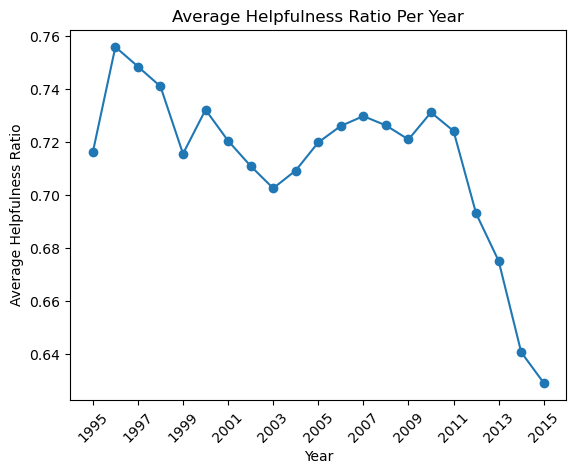

In [32]:
ratio_time_pdf = sqlContext.sql(
    """
    SELECT YEAR(review_date) as year, ROUND(AVG(helpful_votes / total_votes), 4) as avg_ratio
    FROM reviews
    WHERE total_votes > 0 AND YEAR(review_date) BETWEEN 1995 AND 2015
    GROUP BY year
    ORDER BY year
    """).toPandas()

plt.plot(ratio_time_pdf['year'], ratio_time_pdf['avg_ratio'], marker='o')
plt.title('Average Helpfulness Ratio Per Year')
plt.xlabel('Year')
plt.ylabel('Average Helpfulness Ratio')
plt.xticks(ratio_time_pdf['year'][::2].astype(int), rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

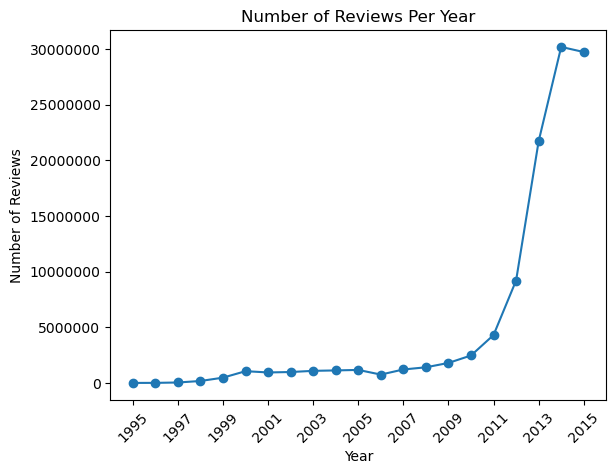

In [33]:
time_pdf = sqlContext.sql(
    """
    SELECT YEAR(review_date) as year, COUNT(*) as count
    FROM reviews
    WHERE YEAR(review_date) BETWEEN 1950 AND 2026
    GROUP BY year
    ORDER BY year
    """).toPandas()

plt.plot(time_pdf['year'], time_pdf['count'], marker='o')
plt.xticks(time_pdf['year'][::2].astype(int), rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Number of Reviews Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()